In [ ]:
from google.colab import drive
from pathlib import Path
from io import StringIO
from bs4 import BeautifulSoup, Comment
import pandas as pd
import matplotlib.pyplot as plt
import requests
import re
import time

In [ ]:
drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/minnesota_analysis")
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"

for folder in (RAW, PROCESSED, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/minnesota_analysis


In [ ]:
# 2. Published SportsDataverse releases
BASE_URL = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores"
)

SEASONS = [2024, 2025, 2026]

def download_team_box(year):
    filename = f"team_box_{year}.parquet"
    destination = RAW / filename

    if destination.exists():
        print(f"Cached: {filename}")
        return destination

    url = f"{BASE_URL}/{filename}"
    print(f"Downloading {year}: {url}")

    with requests.get(
        url,
        stream=True,
        timeout=120
    ) as response:
        response.raise_for_status()

        with open(destination, "wb") as file:
            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    file.write(chunk)

    return destination

# 3. Download and inspect all seasons
season_frames = []

for year in SEASONS:
    try:
        path = download_team_box(year)
        df = pd.read_parquet(path)

        df["research_season"] = (
            f"{year-1}-{str(year)[-2:]}"
        )

        print(f"\n{year}: {len(df):,} rows")
        print("Columns:", df.columns.tolist())

        season_frames.append(df)

    except Exception as error:
        print(f"\nCould not load {year}: {error}")
        print(
            "Check the published release assets "
            "before changing the filename."
        )

    time.sleep(1)

if not season_frames:
    raise RuntimeError(
        "No season datasets were downloaded."
    )

# 4. Combine and save
all_teams = pd.concat(
    season_frames,
    ignore_index=True
)

all_teams.to_parquet(
    PROCESSED / "nba_team_box_2024_2026.parquet",
    index=False
)

print("\nCombined dataset:")
print(all_teams.shape)

display(all_teams.head())

# 5. Inspect columns that may identify Minnesota
team_columns = [
    col for col in all_teams.columns
    if any(
        term in col.lower()
        for term in ["team", "abbrev", "franchise"]
    )
]

print("\nTeam-related columns:")
print(team_columns)

for col in team_columns:
    if all_teams[col].dtype == "object":
        values = (
            all_teams[col]
            .dropna()
            .astype(str)
            .unique()
        )

        if len(values) <= 100:
            print(f"\n{col}:")
            print(values[:100])

Cached: team_box_2024.parquet

2024: 2,640 rows
Columns: ['game_id', 'season', 'season_type', 'game_date', 'game_date_time', 'team_id', 'team_uid', 'team_slug', 'team_location', 'team_name', 'team_abbreviation', 'team_display_name', 'team_short_display_name', 'team_color', 'team_alternate_color', 'team_logo', 'team_home_away', 'team_score', 'team_winner', 'assists', 'blocks', 'defensive_rebounds', 'fast_break_points', 'field_goal_pct', 'field_goals_made', 'field_goals_attempted', 'flagrant_fouls', 'fouls', 'free_throw_pct', 'free_throws_made', 'free_throws_attempted', 'largest_lead', 'offensive_rebounds', 'points_in_paint', 'steals', 'team_turnovers', 'technical_fouls', 'three_point_field_goal_pct', 'three_point_field_goals_made', 'three_point_field_goals_attempted', 'total_rebounds', 'total_technical_fouls', 'total_turnovers', 'turnover_points', 'turnovers', 'opponent_team_id', 'opponent_team_uid', 'opponent_team_slug', 'opponent_team_location', 'opponent_team_name', 'opponent_team_ab

,game_id,season,season_type,game_date,game_date_time,team_id,team_uid,team_slug,team_location,team_name,...,opponent_team_abbreviation,opponent_team_display_name,opponent_team_short_display_name,opponent_team_color,opponent_team_alternate_color,opponent_team_logo,opponent_team_score,research_season,lead_changes,lead_percentage
0,401656363,2024,3,2024-06-17,2024-06-17 20:30:00-04:00,6,s:40~l:46~t:6,dallas-mavericks,Dallas,Mavericks,...,BOS,Boston Celtics,Celtics,008348,ffffff,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,106,2023-24,NaN,NaN
1,401656363,2024,3,2024-06-17,2024-06-17 20:30:00-04:00,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,...,DAL,Dallas Mavericks,Mavericks,0064b1,bbc4ca,https://a.espncdn.com/i/teamlogos/nba/500/dal.png,88,2023-24,NaN,NaN
2,401656362,2024,3,2024-06-14,2024-06-14 20:30:00-04:00,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,...,DAL,Dallas Mavericks,Mavericks,0064b1,bbc4ca,https://a.espncdn.com/i/teamlogos/nba/500/dal.png,122,2023-24,NaN,NaN
3,401656362,2024,3,2024-06-14,2024-06-14 20:30:00-04:00,6,s:40~l:46~t:6,dallas-mavericks,Dallas,Mavericks,...,BOS,Boston Celtics,Celtics,008348,ffffff,https://a.espncdn.com/i/teamlogos/nba/500/bos.png,84,2023-24,NaN,NaN
4,401656361,2024,3,2024-06-12,2024-06-12 20:30:00-04:00,2,s:40~l:46~t:2,boston-celtics,Boston,Celtics,...,DAL,Dallas Mavericks,Mavericks,0064b1,bbc4ca,https://a.espncdn.com/i/teamlogos/nba/500/dal.png,99,2023-24,NaN,NaN



Team-related columns:
['team_id', 'team_uid', 'team_slug', 'team_location', 'team_name', 'team_abbreviation', 'team_display_name', 'team_short_display_name', 'team_color', 'team_alternate_color', 'team_logo', 'team_home_away', 'team_score', 'team_winner', 'team_turnovers', 'opponent_team_id', 'opponent_team_uid', 'opponent_team_slug', 'opponent_team_location', 'opponent_team_name', 'opponent_team_abbreviation', 'opponent_team_display_name', 'opponent_team_short_display_name', 'opponent_team_color', 'opponent_team_alternate_color', 'opponent_team_logo', 'opponent_team_score']

team_uid:
['s:40~l:46~t:6' 's:40~l:46~t:2' 's:40~l:46~t:16' 's:40~l:46~t:11'
 's:40~l:46~t:18' 's:40~l:46~t:7' 's:40~l:46~t:25' 's:40~l:46~t:5'
 's:40~l:46~t:19' 's:40~l:46~t:12' 's:40~l:46~t:15' 's:40~l:46~t:20'
 's:40~l:46~t:14' 's:40~l:46~t:3' 's:40~l:46~t:13' 's:40~l:46~t:21'
 's:40~l:46~t:4' 's:40~l:46~t:23' 's:40~l:46~t:1' 's:40~l:46~t:9'
 's:40~l:46~t:27' 's:40~l:46~t:30' 's:40~l:46~t:28' 's:40~l:46~t:17'


Missing values in the original data:
points      0
fga         0
fgm         0
three_pm    0
fta         0
orb         0
drb         0
tov         0
dtype: int64

DEFENSIVE RATING DIAGNOSTIC
        points         opp_points         possessions          ortg          \
         count    mean      count    mean       count    mean count    mean   
season                                                                        
2023-24     98  112.08         98  106.00          98   98.41    98  114.00   
2024-25     97  113.48         97  108.85          97   99.32    97  114.36   
2025-26     94  116.76         94  114.57          94  102.89    94  113.49   

         drtg          
        count    mean  
season                 
2023-24    98  107.85  
2024-25    97  109.62  
2025-26    94  111.50  

Season-type breakdown:
season_type  Playoffs  Regular Season
season                               
2023-24            16              82
2024-25            15              82
2025-26       

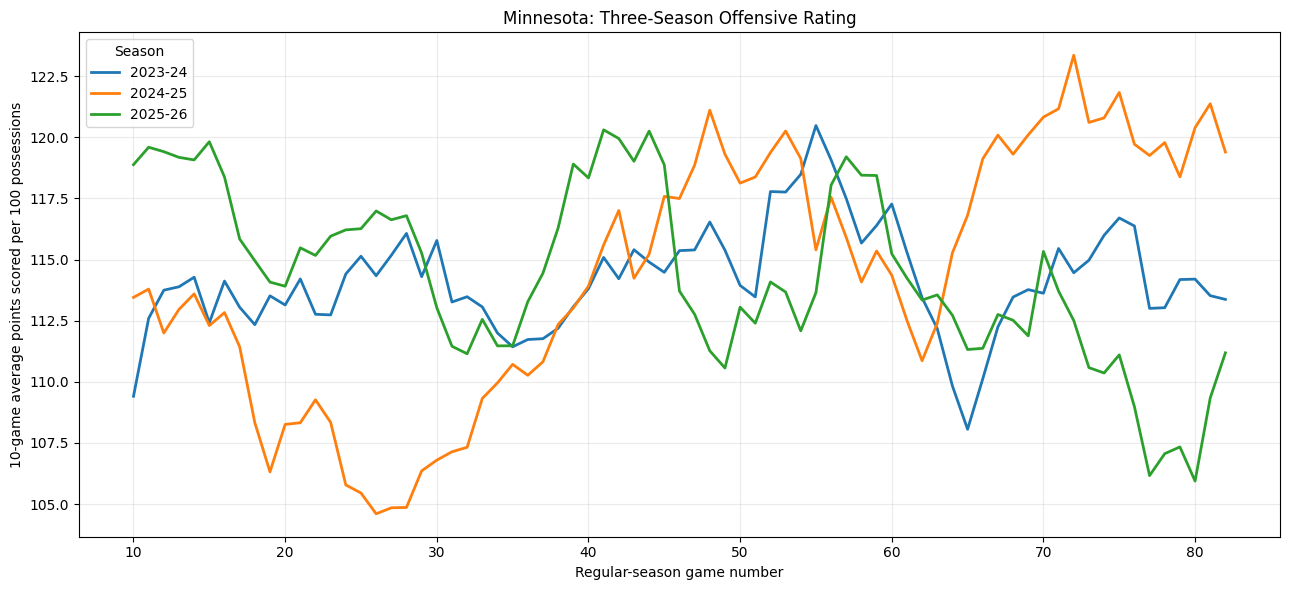

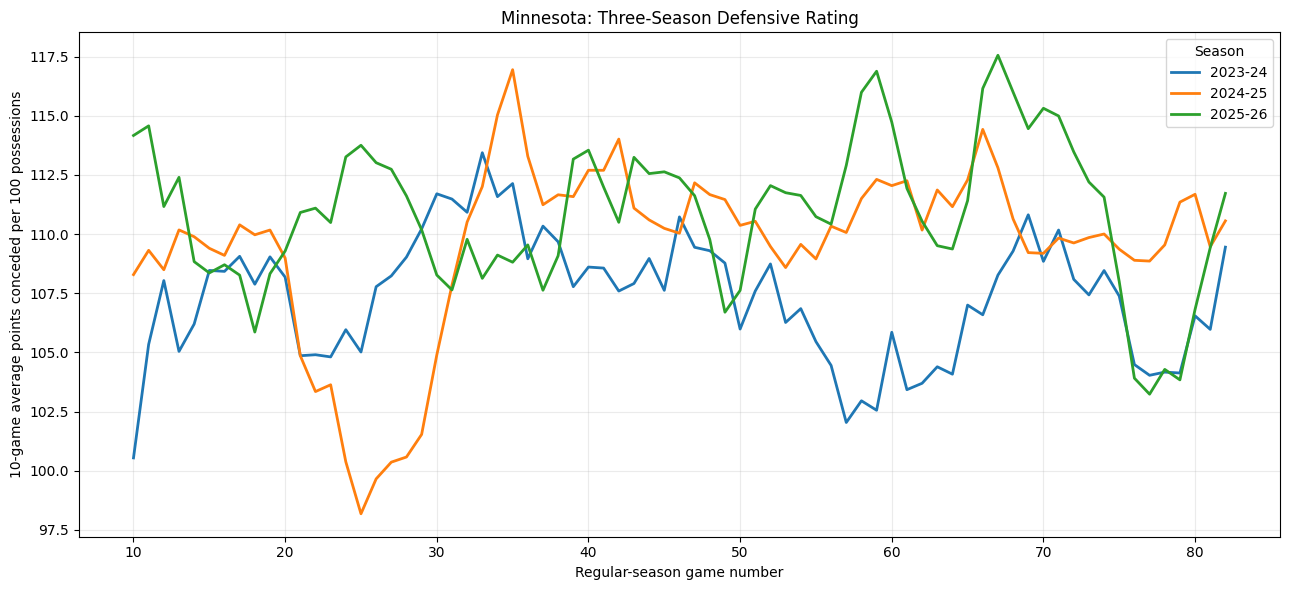

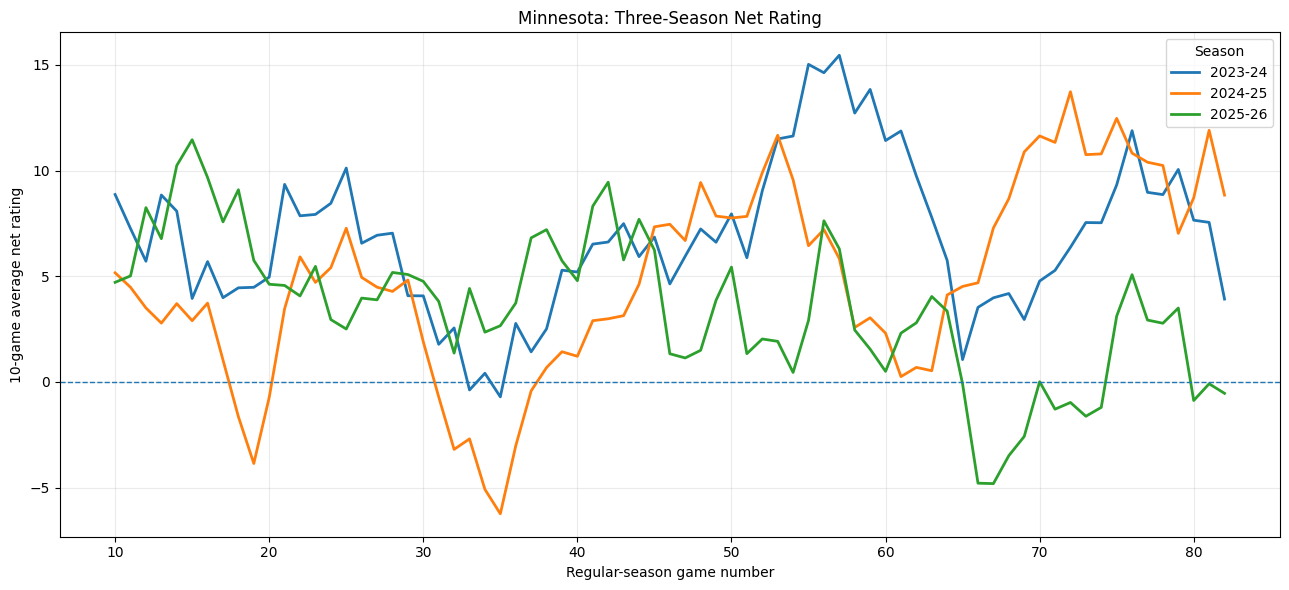

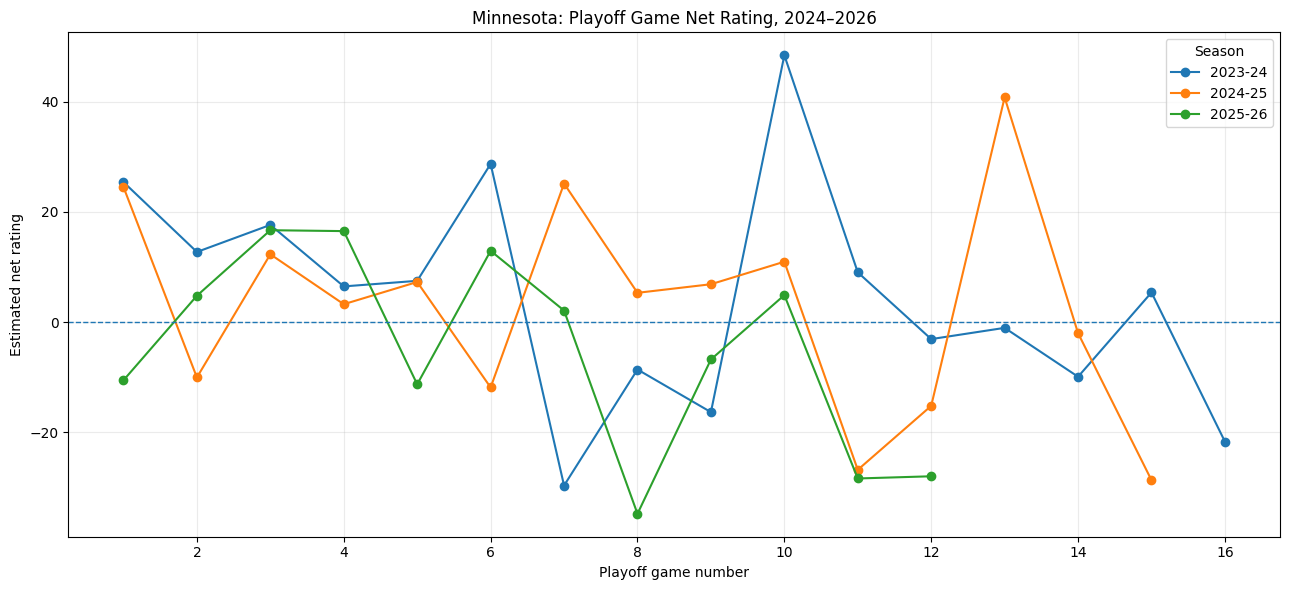


Charts saved to: /content/drive/MyDrive/minnesota_analysis/figures


In [ ]:

# ============================================================
# CATEGORY 1 — THREE-SEASON PERFORMANCE CHARTS
# Requires the `games`, `PROCESSED` and `FIGURES`
# variables from the previous notebook cells.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Rebuild opponent matchups using both team rows.
# Include season in the join to avoid accidental
# cross-season matches.

required = [
    "game_id", "team", "season", "points",
    "fga", "fgm", "three_pm", "fta",
    "orb", "drb", "tov"
]

missing = [c for c in required if c not in games.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")

source = games.copy()

# Remove any old rows with incomplete box scores.
numeric_cols = [
    "points", "fga", "fgm", "three_pm",
    "fta", "orb", "drb", "tov"
]

for col in numeric_cols:
    source[col] = pd.to_numeric(
        source[col], errors="coerce"
    )

print("Missing values in the original data:")
print(source[numeric_cols].isna().sum())

# We must not calculate ratings from missing values.
source = source.dropna(
    subset=numeric_cols
).copy()

source["game_id"] = source["game_id"].astype(str)
source["season"] = source["season"].astype(str)

# Verify one row per team per game.
duplicate_keys = source.duplicated(
    ["season", "game_id", "team"]
)

if duplicate_keys.any():
    raise ValueError(
        "Duplicate team-game rows detected. "
        "Inspect the source before proceeding."
    )

# Retain games with two complete team box scores.
counts = source.groupby(
    ["season", "game_id"]
)["team"].nunique()

complete_games = counts[counts == 2].index

source = source.set_index(
    ["season", "game_id"]
).loc[complete_games].reset_index()

# Rename the second copy as the opponent.
opponent = source[
    ["season", "game_id", "team"] + numeric_cols
].rename(
    columns={
        "team": "opponent",
        **{c: f"opp_{c}" for c in numeric_cols}
    }
)

paired = source.merge(
    opponent,
    on=["season", "game_id"],
    validate="many_to_many"
)

paired = paired[
    paired["team"] != paired["opponent"]
].copy()

# Keep only Minnesota.
min_df = paired[
    paired["team"].str.contains(
        r"Minnesota|Timberwolves|^MIN$",
        case=False,
        regex=True,
        na=False
    )
].copy()

if min_df.empty:
    raise ValueError(
        "No Minnesota rows found. "
        "Check the team labels."
    )

# 2. Calculate possessions and ratings.
min_df["team_poss"] = (
    min_df["fga"]
    - min_df["orb"]
    + min_df["tov"]
    + 0.44 * min_df["fta"]
)

min_df["opp_poss"] = (
    min_df["opp_fga"]
    - min_df["opp_orb"]
    + min_df["opp_tov"]
    + 0.44 * min_df["opp_fta"]
)

min_df["possessions"] = (
    min_df["team_poss"] + min_df["opp_poss"]
) / 2

if (
    min_df["possessions"].isna().any()
    or (min_df["possessions"] <= 0).any()
):
    raise ValueError("Invalid possession estimates.")

min_df["ortg"] = (
    100 * min_df["points"] / min_df["possessions"]
)

min_df["drtg"] = (
    100 * min_df["opp_points"] / min_df["possessions"]
)

min_df["net_rating"] = (
    min_df["ortg"] - min_df["drtg"]
)

# 3. Diagnose the previously missing DRtg.
print("\nDEFENSIVE RATING DIAGNOSTIC")
print(
    min_df.groupby("season")[
        ["points", "opp_points",
         "possessions", "ortg", "drtg"]
    ].agg(["count", "mean"]).round(2)
)

if min_df["drtg"].isna().any():
    raise ValueError(
        "Defensive rating is still missing. "
        "Inspect opponent points and possessions."
    )

# 4. Separate regular season from playoffs.
# SportsDataverse may use numeric ESPN season types:
# 2 = regular season, 3 = postseason.
# Unrecognized labels are not silently classified.

if "season_type_raw" not in min_df.columns:
    raise ValueError(
        "No season_type_raw column found. "
        "We need the source's season-type field "
        "to distinguish regular season and playoffs."
    )

def classify_season_type(value):
    text = str(value).strip().lower()

    if text in ("2", "2.0", "regular",
                "regular season", "regularseason"):
        return "Regular Season"

    if text in ("3", "3.0", "postseason",
                "playoffs", "playoff"):
        return "Playoffs"

    return "Unknown"

min_df["season_type"] = (
    min_df["season_type_raw"]
    .apply(classify_season_type)
)

print("\nSeason-type breakdown:")
print(
    pd.crosstab(
        min_df["season"],
        min_df["season_type"]
    )
)

if (min_df["season_type"] == "Unknown").any():
    print(
        "\nUnrecognized source labels:",
        min_df.loc[
            min_df["season_type"] == "Unknown",
            "season_type_raw"
        ].unique()
    )
    raise ValueError(
        "Verify the unknown season-type labels "
        "before generating the charts."
    )

if "date" not in min_df.columns:
    raise ValueError(
        "Missing game dates. "
        "Chronological charts require a date column."
    )

min_df["date"] = pd.to_datetime(
    min_df["date"], errors="coerce"
)

if min_df["date"].isna().any():
    raise ValueError("Some game dates could not be parsed.")

min_df = min_df.sort_values(
    ["season", "season_type", "date"]
).copy()

# 5. Print how many games we actually have.
print("\nCOLLECTED GAMES")
print(
    pd.crosstab(
        min_df["season"],
        min_df["season_type"]
    )
)

# Save corrected dataset.
min_df.to_csv(
    PROCESSED / "minnesota_corrected_ratings.csv",
    index=False
)

# 6. Prepare regular-season rolling averages.
regular = min_df[
    min_df["season_type"] == "Regular Season"
].copy()

regular["game_number"] = (
    regular.groupby("season").cumcount() + 1
)

for metric in ["ortg", "drtg", "net_rating"]:
    regular[f"rolling_{metric}"] = (
        regular.groupby("season")[metric]
        .transform(
            lambda s: s.rolling(
                window=10,
                min_periods=10
            ).mean()
        )
    )

# 7. Chart A — Three-season offensive rating.
fig, ax = plt.subplots(figsize=(13, 6))

for season, group in regular.groupby("season"):
    ax.plot(
        group["game_number"],
        group["rolling_ortg"],
        linewidth=2,
        label=season
    )

ax.set(
    title="Minnesota: Three-Season Offensive Rating",
    xlabel="Regular-season game number",
    ylabel="10-game average points scored per 100 possessions"
)

ax.legend(title="Season")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    FIGURES / "three_seasons_offensive_rating.png",
    dpi=200
)
plt.show()

# 8. Chart B — Three-season defensive rating.
fig, ax = plt.subplots(figsize=(13, 6))

for season, group in regular.groupby("season"):
    ax.plot(
        group["game_number"],
        group["rolling_drtg"],
        linewidth=2,
        label=season
    )

ax.set(
    title="Minnesota: Three-Season Defensive Rating",
    xlabel="Regular-season game number",
    ylabel="10-game average points conceded per 100 possessions"
)

ax.legend(title="Season")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    FIGURES / "three_seasons_defensive_rating.png",
    dpi=200
)
plt.show()

# 9. Chart C — Three-season net rating.
fig, ax = plt.subplots(figsize=(13, 6))

for season, group in regular.groupby("season"):
    ax.plot(
        group["game_number"],
        group["rolling_net_rating"],
        linewidth=2,
        label=season
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set(
    title="Minnesota: Three-Season Net Rating",
    xlabel="Regular-season game number",
    ylabel="10-game average net rating"
)

ax.legend(title="Season")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    FIGURES / "three_seasons_net_rating.png",
    dpi=200
)
plt.show()

# 10. Chart D — Playoff game net rating.
playoffs = min_df[
    min_df["season_type"] == "Playoffs"
].copy()

playoffs["playoff_game_number"] = (
    playoffs.groupby("season").cumcount() + 1
)

fig, ax = plt.subplots(figsize=(13, 6))

for season, group in playoffs.groupby("season"):
    ax.plot(
        group["playoff_game_number"],
        group["net_rating"],
        marker="o",
        linewidth=1.5,
        label=season
    )

ax.axhline(0, linestyle="--", linewidth=1)

ax.set(
    title="Minnesota: Playoff Game Net Rating, 2024–2026",
    xlabel="Playoff game number",
    ylabel="Estimated net rating"
)

ax.legend(title="Season")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(
    FIGURES / "three_seasons_playoff_net_rating.png",
    dpi=200
)
plt.show()

print("\nCharts saved to:", FIGURES)